# SETUP

## Commencement AWS : Création utilisateur

On fournit des autorisations administratives pour S3 et en général. Clé activée.  
Télécharger le csv qui contient la paire de clés.

## Commencement local : pip install awscli

**Configuration AWS**
- On rentre l'ID et la clé secrète pour l'utilisateur 
- On choisit la localisation `eu-west-3` pour avoir les serveurs à Paris : rapidité et protection des données selon la législature européenne  
- Format de sortie par défaut : JSON

## Création d'un bucket S3

On se positionne dans le dossier Test et on fait une synchronisation avec le bucket
aws s3 sync C:\chemin\vers\fruits-360\Test s3://NOM-BUCKET/data/fruits-360/Test

On importe nos documents dans le dossier

aws s3 cp bootstrap.sh   s3://NOM-BUCKET/code/bootstrap.sh  
aws s3 cp p9_pipeline.py s3://NOM-BUCKET/code/p9_pipeline.py  

## Création clés SSH

Les clés SSH sont un moyen sécurisé d'établir une connexion entre deux machines via un réseau non sécurisé.  
Elles sont essentielles pour lancer une machine EMR (qui se repose sur les machines EC2).  
RSA : Recommandé pour une compatibilité maximale.

- `.pem` : OpenSSH, compatible Linux  
- `.ppk` : PuTTY, compatible Windows (celle qu'on va utiliser)

## Autorisation du tunnel SSH dans AWS

Par défaut, AWS bloque l'accès au port 22 (SSH) pour des raisons de sécurité.  
En autorisant le tunnel SSH à travers le port 22 dans le firewall d'AWS, on peut établir une connexion sécurisée et accéder à JupyterHub et aux logs de Spark depuis notre machine locale.

## Configuration du serveur EMR

- Sélectionner : Spark, Hadoop, TensorFlow, JupyterHub (attention à la compatibilité des versions)  
- Configuration de cluster : Flottes d'instances flexibles  
  - Instance maître : `m5.xlarge`  
  - Instance nœud : `m5.xlarge`  
  - **2 noeuds**
- Activer : *Résilier automatiquement le cluster après le temps d'inactivité*, ici 1h    
- Ajouter une action d'amorçage : installation de packages à tous les niveaux du cluster  
- Donner les autorisations lecture/écriture S3 aux instances

## Établir le tunnel SSH avec le cluster

- Cliquer sur *Connexion au nœud primaire à l'aide de SSH*  
- Ouvrir PuTTY, ajouter le lien, charger la clé `.ppk`, accepter  
- Configurer le navigateur pour utiliser le tunnel SSH (proxy SOCKS)

## Tutoriels Vidéo

- Création EMR Cluster : https://youtu.be/31cPwmoM6yY?si=TXY56tBFnAa3o7nJ  
- Cr"ation EMR Studio : https://youtu.be/qkWYm7pK2gM?si=MBniHMtrAd7uXx0G

# EMR Studio / JupyterHub Code

## Setup

In [ ]:
%%configure -f
{
  "conf": {
    "spark.pyspark.python": "/usr/bin/python3",
    "spark.pyspark.driver.python": "/usr/bin/python3"
  }
}

In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.linalg import Vectors

import io
import os
import tensorflow as tf
from PIL import Image
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras import Model
from pyspark.sql.functions import col, pandas_udf, PandasUDFType, element_at, split
from pyspark.sql import SparkSession

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [6]:
%%info

ID,YARN Application ID,Kind,State,Spark UI,Driver log,User,Current session?
6,application_1778572152659_0007,pyspark,idle,Link,Link,None,✔


In [8]:
PATH        = 's3://nons-bucket-p9-096766144198-eu-west-3-an'
PATH_Data   = PATH + '/data/Test'
PATH_Result = PATH + '/data/Results'
PATH_PCA    = PATH + '/data/PCA'
print('PATH:        ' + PATH +
      '\nPATH_Data:   ' + PATH_Data +
      '\nPATH_Result: ' + PATH_Result +
      '\nPATH_PCA:    ' + PATH_PCA)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

PATH:        s3://nons-bucket-p9-096766144198-eu-west-3-an
PATH_Data:   s3://nons-bucket-p9-096766144198-eu-west-3-an/data/Test
PATH_Result: s3://nons-bucket-p9-096766144198-eu-west-3-an/data/Results
PATH_PCA:    s3://nons-bucket-p9-096766144198-eu-west-3-an/data/PCA

In [9]:
# ============================================================
# MODE D'EXÉCUTION
# TEST_MODE = True  → échantillon limité (rapide, pour valider le pipeline)
# TEST_MODE = False → dataset complet   (run de production)
# ============================================================
TEST_MODE   = True
TEST_SAMPLE = 100   # nombre d'images à utiliser en mode test

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

## Import dataset

In [ ]:
images = spark.read.format('binaryFile') \
    .option('pathGlobFilter', '*.jpg') \
    .option('recursiveFileLookup', 'true') \
    .load(PATH_Data)

In [ ]:
images = images.withColumn('label', element_at(split(images['path'], '/'), -2))
print(images.printSchema())
print(images.select('path', 'label').show(5, False))

In [12]:
if TEST_MODE:
    images = images.sample(fraction=0.05, seed=42).limit(TEST_SAMPLE)
    print(f'MODE TEST — {images.count()} images chargées (limite : {TEST_SAMPLE})')
else:
    print(f'MODE COMPLET — {images.count()} images chargées')

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

MODE TEST ? 100 images charg?es (limite : 100)

## Setup model

In [13]:
model = MobileNetV2(weights='imagenet',
                    include_top=True,
                    input_shape=(224, 224, 3))

new_model = Model(inputs=model.input,
                  outputs=model.layers[-2].output)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [14]:
brodcast_weights = sc.broadcast(new_model.get_weights())

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

## Utils

In [15]:
def model_fn():
    """
    Returns a MobileNetV2 model with top layer removed
    and broadcasted pretrained weights.
    """
    model = MobileNetV2(weights='imagenet',
                        include_top=True,
                        input_shape=(224, 224, 3))
    for layer in model.layers:
        layer.trainable = False
    new_model = Model(inputs=model.input,
                      outputs=model.layers[-2].output)
    new_model.set_weights(brodcast_weights.value)
    return new_model

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [16]:
def preprocess(content):
    """
    Preprocesses raw image bytes for prediction.
    """
    img = Image.open(io.BytesIO(content)).convert('RGB').resize([224, 224])
    arr = img_to_array(img)
    return preprocess_input(arr)


def featurize_series(model, content_series):
    """
    Featurize a pd.Series of raw images using the input model.
    :return: a pd.Series of image features
    """
    input = np.stack(content_series.map(preprocess))
    preds = model.predict(input)
    output = [p.flatten() for p in preds]
    return pd.Series(output)


@pandas_udf('array<float>', PandasUDFType.SCALAR_ITER)
def featurize_udf(content_series_iter):
    """
    Scalar Iterator pandas UDF wrapping our featurization function.
    Loads the model once and reuses it across batches to amortize overhead.
    """
    model = model_fn()
    for content_series in content_series_iter:
        yield featurize_series(model, content_series)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

/mnt1/yarn/usercache/livy/appcache/application_1778572152659_0007/container_1778572152659_0007_01_000001/pyspark.zip/pyspark/sql/pandas/functions.py:407: UserWarning: In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.

In [17]:
spark.conf.set('spark.sql.execution.arrow.maxRecordsPerBatch', '1024')

features_df = images.repartition(24).select(
    col('path'),
    col('label'),
    featurize_udf('content').alias('features')
)

features_df.write.mode('overwrite').parquet(PATH_Result)
print('Features écrites dans', PATH_Result)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Features ?crites dans s3://nons-bucket-p9-096766144198-eu-west-3-an/data/Results

## PCA avec StandardScaler

Pipeline :
1. `VectorAssembler` : column `features` (array) → `features_vec` (DenseVector)
2. `StandardScaler` : centrage et réduction (`withMean=True`, `withStd=True`) → `features_scaled`
3. PCA exploratoire (`k_max=200`) + recherche du k optimal (seuils 80 / 90 / 95 %)
4. PCA finale avec `k_optimal` (cible 90 %) → `pcaFeatures`

In [18]:
# Cellule 1 - Configuration Spark
import os
os.environ["SPARK_HOME"] = "/usr/lib/spark"
os.environ["PYSPARK_PYTHON"] = "/usr/bin/python3"
import sys
sys.path.insert(0, "/usr/lib/spark/python")
sys.path.insert(0, "/usr/lib/spark/python/lib/py4j-src.zip")

# Cellule 2 - Tous les imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
matplotlib.use('Agg')
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.linalg import Vectors

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [20]:
df = pd.read_parquet(PATH_Result, engine='pyarrow')
print(f'Shape                  : {df.shape}')
print(f'Taille vecteur features: {df.loc[0, "features"].shape}')
df.head()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Shape                  : (100, 3)
Taille vecteur features: (1280,)
                                                path  ...                                           features
0  s3://nons-bucket-p9-096766144198-eu-west-3-an/...  ...  [1.152262, 0.29961953, 0.0, 0.0, 0.0, 0.002981...
1  s3://nons-bucket-p9-096766144198-eu-west-3-an/...  ...  [0.34706318, 0.5310822, 0.0, 0.0, 0.0, 0.34656...
2  s3://nons-bucket-p9-096766144198-eu-west-3-an/...  ...  [0.33468467, 0.40677762, 0.7894823, 0.0, 0.0, ...
3  s3://nons-bucket-p9-096766144198-eu-west-3-an/...  ...  [2.482546, 0.261092, 0.2154804, 0.0, 0.0, 0.0,...
4  s3://nons-bucket-p9-096766144198-eu-west-3-an/...  ...  [0.64713186, 0.0, 0.0388256, 0.0, 0.0, 0.0, 1....

[5 rows x 3 columns]

In [21]:
spark.sparkContext.setLogLevel('ERROR')
spark.conf.set('spark.sql.execution.arrow.maxRecordsPerBatch', '1024')

df['features'] = df['features'].apply(lambda x: Vectors.dense(x))
data_spark = spark.createDataFrame(df)

vecAssembler = VectorAssembler(inputCols=['features'], outputCol='features_vec')
data_spark = vecAssembler.transform(data_spark)
print('VectorAssembler OK')

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

VectorAssembler OK

In [22]:
scaler = StandardScaler(
    inputCol='features_vec',
    outputCol='features_scaled',
    withMean=True,
    withStd=True
)
scalerModel = scaler.fit(data_spark)
data_scaled = scalerModel.transform(data_spark).cache()
print('StandardScaler OK — features centrées (mean=0) et réduites (std=1)')

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

StandardScaler OK ? features centr?es (mean=0) et r?duites (std=1)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

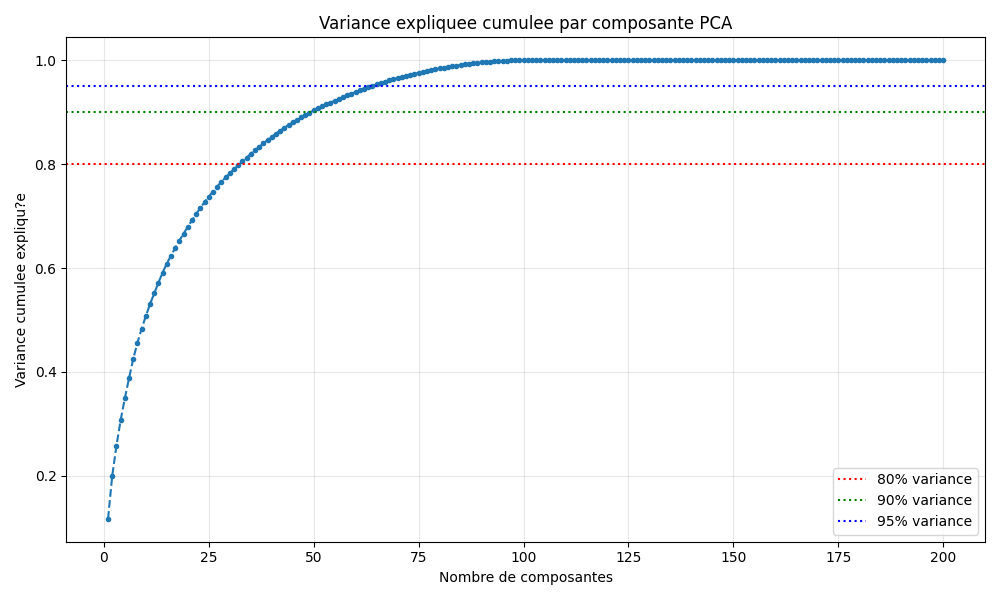

In [30]:
k_max = 200
pca_exp = PCA(k=k_max, inputCol='features_scaled', outputCol='pcaFeatures')
pcaModel_exp = pca_exp.fit(data_scaled)
cumValues = pcaModel_exp.explainedVariance.cumsum()

print('Recherche du k optimal :')
for seuil in [0.80, 0.90, 0.95]:
    mask = cumValues >= seuil
    if mask.any():
        K = int(np.argmax(mask) + 1)
        print(f'  {int(seuil * 100)}% de variance atteint avec k = {K}')
    else:
        print(f'  {int(seuil * 100)}% non atteint avec k_max={k_max} '
              f'(max = {cumValues[-1] * 100:.1f}%)')

plt.figure(figsize=(10, 6))
plt.plot(range(1, k_max + 1), cumValues, marker='o', linestyle='--', markersize=3)
plt.axhline(y=0.80, color='r', linestyle=':', label='80% variance')
plt.axhline(y=0.90, color='g', linestyle=':', label='90% variance')
plt.axhline(y=0.95, color='b', linestyle=':', label='95% variance')
plt.title('Variance expliquee cumulee par composante PCA')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance cumulee expliquée')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

%matplot plt

In [24]:
seuil_cible = 0.90
mask = cumValues >= seuil_cible
k_optimal = int(np.argmax(mask) + 1) if mask.any() else k_max
print(f'PCA finale avec k = {k_optimal} composantes '
      f'({int(seuil_cible * 100)}% de variance expliquée)')

pca_final = PCA(k=k_optimal, inputCol='features_scaled', outputCol='pcaFeatures')
model_pca = pca_final.fit(data_scaled)
result = model_pca.transform(data_scaled)

result = result.drop('features_vec', 'features_scaled')
result.show(5)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

PCA finale avec k = 50 composantes (90% de variance expliqu?e)
+--------------------+-----------------+--------------------+--------------------+
|                path|            label|            features|         pcaFeatures|
+--------------------+-----------------+--------------------+--------------------+
|s3://nons-bucket-...|           pear_1|[1.15226197242736...|[-7.7613261016396...|
|s3://nons-bucket-...|apple_pink_lady_1|[0.34706318378448...|[11.6930081472170...|
|s3://nons-bucket-...|      apple_hit_1|[0.33468466997146...|[-15.793098020856...|
|s3://nons-bucket-...|           pear_1|[2.48254609107971...|[-16.418200355477...|
|s3://nons-bucket-...|      apple_red_3|[0.64713186025619...|[8.22922448175939...|
+--------------------+-----------------+--------------------+--------------------+
only showing top 5 rows

In [ ]:
result.write.mode('overwrite').parquet(PATH_PCA)
print('Résultat PCA écrit dans', PATH_PCA)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

R?sultat PCA ?crit dans s3://nons-bucket-p9-096766144198-eu-west-3-an/data/PCA

In [26]:
df_pca = spark.read.parquet(PATH_PCA).toPandas()
print(f'Shape final : {df_pca.shape}')
print(f'Colonnes    : {list(df_pca.columns)}')
df_pca.head()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Shape final : (100, 4)
Colonnes    : ['path', 'label', 'features', 'pcaFeatures']
                                                path  ...                                        pcaFeatures
0  s3://nons-bucket-p9-096766144198-eu-west-3-an/...  ...  [13.1671977859621, 3.3140839569064586, -0.0811...
1  s3://nons-bucket-p9-096766144198-eu-west-3-an/...  ...  [-2.1163204894153425, 8.781834329432519, -0.49...
2  s3://nons-bucket-p9-096766144198-eu-west-3-an/...  ...  [-16.622058585689995, -2.777470027227709, 0.19...
3  s3://nons-bucket-p9-096766144198-eu-west-3-an/...  ...  [8.260349014234649, 2.1325663938514143, -0.630...
4  s3://nons-bucket-p9-096766144198-eu-west-3-an/...  ...  [6.589664544462906, -1.1361986573843654, -2.60...

[5 rows x 4 columns]